In [ ]:
import os
import numpy as np
import pandas as pd
import random
import time
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
import json

import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Activation, ZeroPadding1D, GlobalAveragePooling1D, Add, Concatenate, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

random.seed(20)
np.random.seed(20)
tf.random.set_seed(20)

2026-05-20 14:02:21.423117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779285741.803479      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779285741.904104      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779285742.899550      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779285742.899594      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779285742.899597      23 computation_placer.cc:177] computation placer alr

In [ ]:
config = {
    "data_dir": "/kaggle/input/datasets/lampdp/masque-300-web", 
    
    "batch_size": 50,
    "seq_length": 3000,
    "learning_rate": 0.0005,
    "max_epochs": 200,
    "base_patience": 30,
    "lr_patience": 5,          # Dùng cho ReduceLROnPlateau (giảm LR sớm hơn)
    "dir_dilations": True,
    "time_dilations": True,
    "inter_time": True,       # Dùng inter-packet time thay vì relative time
    "scale_metadata": True,
    "test_size": 0.1,         # Tỉ lệ chia tập test
    "val_size": 0.05,         # Tỉ lệ chia tập validation (từ tập train)
    
    "features_to_use": ["dir", "time", "metadata"] 
}

In [ ]:
def load_and_preprocess_data(config):
    data_dir = config['data_dir']
    seq_length = config['seq_length']
    
    dir_seqs, time_seqs, metadatas, labels = [], [], [], []
    
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"Found {len(classes)} classes (folders).")
    
    for label_name in tqdm(classes, desc="Processing folders"):
        class_dir = os.path.join(data_dir, label_name)
        files = [f for f in os.listdir(class_dir) if f.endswith('.csv')]
        
        for file in files:
            filepath = os.path.join(class_dir, file)

            df = pd.read_csv(filepath, sep=';')
            
            if len(df) == 0:
                continue
                
            # Lấy direction (giả sử 0 là incoming, 1 là outgoing. Đổi 0 thành -1 để dễ học)
            dirs = df['direction'].values
            dirs = np.where(dirs == 0, -1, 1)
            times = df['relative_time'].values
            
            # Khởi tạo chuỗi sequence
            dir_seq = np.zeros(seq_length, dtype=np.int8)
            time_seq = np.zeros(seq_length, dtype=np.float32)
            
            limit = min(len(dirs), seq_length)
            dir_seq[:limit] = dirs[:limit]
            time_seq[:limit] = times[:limit]
            
            # Tính metadata
            total_incoming = np.sum(dirs == -1)
            total_outgoing = np.sum(dirs == 1)
            total_packets = total_incoming + total_outgoing
            total_time = times[-1] if total_packets > 0 else 0.0
            
            if total_packets == 0:
                metadata = np.zeros(7, dtype=np.float32)
            else:
                metadata = np.array([
                    total_packets, 
                    total_incoming, 
                    total_outgoing,
                    total_incoming / total_packets,
                    total_outgoing / total_packets,
                    total_time, 
                    total_time / total_packets
                ], dtype=np.float32)
                
            dir_seqs.append(dir_seq)
            time_seqs.append(time_seq)
            metadatas.append(metadata)
            labels.append(label_name)

    # Convert to Numpy Arrays
    dir_seqs = np.array(dir_seqs)
    time_seqs = np.array(time_seqs)
    metadatas = np.array(metadatas)
    
    # Inter-time calculation (thời gian giữa các gói tin liên tiếp)
    if config['inter_time']:
        inter_time_seqs = np.zeros_like(time_seqs)
        inter_time_seqs[:, 1:] = time_seqs[:, 1:] - time_seqs[:, :-1]
        time_seqs = inter_time_seqs
        
    # Reshape cho Conv1D (samples, steps, channels)
    dir_seqs = np.expand_dims(dir_seqs, axis=-1)
    time_seqs = np.expand_dims(time_seqs, axis=-1)
    
    # Encode Labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(labels)
    y_categorical = to_categorical(y_encoded)
    
    # Chia Train / Test
    X_dir_train, X_dir_test, X_time_train, X_time_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
        dir_seqs, time_seqs, metadatas, y_categorical, test_size=config['test_size'], random_state=42, stratify=y_encoded
    )
    
    # Scale Metadata
    if config['scale_metadata']:
        scaler = StandardScaler()
        X_meta_train = scaler.fit_transform(X_meta_train)
        X_meta_test = scaler.transform(X_meta_test)
        
    print(f"Train data shape: Dir {X_dir_train.shape}, Time {X_time_train.shape}, Meta {X_meta_train.shape}")
    print(f"Test data shape: Dir {X_dir_test.shape}, Time {X_time_test.shape}, Meta {X_meta_test.shape}")
    
    return (X_dir_train, X_time_train, X_meta_train, y_train), (X_dir_test, X_time_test, X_meta_test, y_test), le

(X_dir_train, X_time_train, X_meta_train, y_train), (X_dir_test, X_time_test, X_meta_test, y_test), label_encoder = load_and_preprocess_data(config)

Found 300 classes (folders).


Processing folders:   0%|          | 0/300 [00:00<?, ?it/s]

Train data shape: Dir (133509, 3000, 1), Time (133509, 3000, 1), Meta (133509, 7)
Test data shape: Dir (14835, 3000, 1), Time (14835, 3000, 1), Meta (14835, 7)


In [ ]:
parameters = {'kernel_initializer': 'he_normal'}

def dilated_basic_1d(filters, suffix, stage=0, block=0, kernel_size=3, numerical_name=False, stride=None, dilations=(1, 1)):
    if stride is None:
        stride = 1 if block != 0 or stage == 0 else 2
    block_char = f'b{block}' if block > 0 and numerical_name else chr(ord('a') + block)
    stage_char = str(stage + 2)

    def f(x):
        y = Conv1D(filters, kernel_size, padding='causal', strides=stride, dilation_rate=dilations[0], use_bias=False, name=f'res{stage_char}{block_char}_branch2a_{suffix}', **parameters)(x)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2a_{suffix}')(y)
        y = Activation('relu', name=f'res{stage_char}{block_char}_branch2a_relu_{suffix}')(y)

        y = Conv1D(filters, kernel_size, padding='causal', use_bias=False, dilation_rate=dilations[1], name=f'res{stage_char}{block_char}_branch2b_{suffix}', **parameters)(y)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2b_{suffix}')(y)

        if block == 0:
            shortcut = Conv1D(filters, 1, strides=stride, use_bias=False, name=f'res{stage_char}{block_char}_branch1_{suffix}', **parameters)(x)
            shortcut = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch1_{suffix}')(shortcut)
        else:
            shortcut = x

        y = Add(name=f'res{stage_char}{block_char}_{suffix}')([y, shortcut])
        y = Activation('relu', name=f'res{stage_char}{block_char}_relu_{suffix}')(y)
        return y
    return f

def basic_1d(filters, suffix, stage=0, block=0, kernel_size=3, numerical_name=False, stride=None, dilations=(1, 1)):
    if stride is None:
        stride = 1 if block != 0 or stage == 0 else 2
    dilations = (1, 1)
    block_char = f'b{block}' if block > 0 and numerical_name else chr(ord('a') + block)
    stage_char = str(stage + 2)

    def f(x):
        y = Conv1D(filters, kernel_size, padding='same', strides=stride, dilation_rate=dilations[0], use_bias=False, name=f'res{stage_char}{block_char}_branch2a_{suffix}', **parameters)(x)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2a_{suffix}')(y)
        y = Activation('relu', name=f'res{stage_char}{block_char}_branch2a_relu_{suffix}')(y)

        y = Conv1D(filters, kernel_size, padding='same', use_bias=False, dilation_rate=dilations[1], name=f'res{stage_char}{block_char}_branch2b_{suffix}', **parameters)(y)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2b_{suffix}')(y)

        if block == 0:
            shortcut = Conv1D(filters, 1, strides=stride, use_bias=False, name=f'res{stage_char}{block_char}_branch1_{suffix}', **parameters)(x)
            shortcut = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch1_{suffix}')(shortcut)
        else:
            shortcut = x

        y = Add(name=f'res{stage_char}{block_char}_{suffix}')([y, shortcut])
        y = Activation('relu', name=f'res{stage_char}{block_char}_relu_{suffix}')(y)
        return y
    return f

def ResNet18(inputs, suffix, blocks=[2, 2, 2, 2], block=dilated_basic_1d, numerical_names=[True]*4):
    x = ZeroPadding1D(padding=3, name=f'padding_conv1_{suffix}')(inputs)
    x = Conv1D(64, 7, strides=2, use_bias=False, name=f'conv1_{suffix}')(x)
    x = BatchNormalization(epsilon=1e-5, name=f'bn_conv1_{suffix}')(x)
    x = Activation('relu', name=f'conv1_relu_{suffix}')(x)
    x = MaxPooling1D(3, strides=2, padding='same', name=f'pool1_{suffix}')(x)

    features = 64
    for stage_id, iterations in enumerate(blocks):
        x = block(features, suffix, stage_id, 0, dilations=(1, 2), numerical_name=False)(x)
        for block_id in range(1, iterations):
            x = block(features, suffix, stage_id, block_id, dilations=(4, 8), numerical_name=(block_id > 0 and numerical_names[stage_id]))(x)
        features *= 2
        
    x = GlobalAveragePooling1D(name=f'pool5_{suffix}')(x)
    return x

def build_varcnn_model(config, num_classes):
    seq_length = config['seq_length']
    features = config['features_to_use']
    
    input_params = []
    concat_params = []
    
    if "dir" in features:
        dir_input = Input(shape=(seq_length, 1,), name='dir_input')
        dir_block = dilated_basic_1d if config['dir_dilations'] else basic_1d
        dir_output = ResNet18(dir_input, 'dir', block=dir_block)
        input_params.append(dir_input)
        concat_params.append(dir_output)
        
    if "time" in features:
        time_input = Input(shape=(seq_length, 1,), name='time_input')
        time_block = dilated_basic_1d if config['time_dilations'] else basic_1d
        time_output = ResNet18(time_input, 'time', block=time_block)
        input_params.append(time_input)
        concat_params.append(time_output)
        
    if "metadata" in features:
        metadata_input = Input(shape=(7,), name='metadata_input')
        metadata_output = Dense(32)(metadata_input)
        metadata_output = BatchNormalization()(metadata_output)
        metadata_output = Activation('relu')(metadata_output)
        input_params.append(metadata_input)
        concat_params.append(metadata_output)

    if len(concat_params) == 1:
        combined = concat_params[0]
    else:
        combined = Concatenate()(concat_params)
        combined = Dense(1024)(combined)
        combined = BatchNormalization()(combined)
        combined = Activation('relu')(combined)
        combined = Dropout(0.7)(combined)

    model_output = Dense(units=num_classes, activation='softmax', name='model_output')(combined)
    
    model = Model(inputs=input_params, outputs=model_output)
    # Sử dụng learning_rate từ biến config
    model.compile(
        loss='categorical_crossentropy', 
        optimizer=Adam(learning_rate=config['learning_rate']), 
        metrics=['accuracy']
    )
    return model

num_classes = y_train.shape[1]
model = build_varcnn_model(config, num_classes)
model.summary()

I0000 00:00:1779289811.298308      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779289811.310709      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dir_input           │ (None, 3000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_input          │ (None, 3000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_conv1_dir   │ (None, 3006, 1)   │          0 │ dir_input[0][0]   │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_conv1_time  │ (None, 3006, 1)   │          0 │ time_input[0][0]  │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_dir (Conv1D)  │ (None, 1500, 64)  │        448 │ padding_conv1_di… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_time (Conv1D) │ (None, 1500, 64)  │        448 │ padding_conv1_ti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1_dir        │ (None, 1500, 64)  │        256 │ conv1_dir[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1_time       │ (None, 1500, 64)  │        256 │ conv1_time[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu_dir      │ (None, 1500, 64)  │          0 │ bn_conv1_dir[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu_time     │ (None, 1500, 64)  │          0 │ bn_conv1_time[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_dir           │ (None, 750, 64)   │          0 │ conv1_relu_dir[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_time          │ (None, 750, 64)   │          0 │ conv1_relu_time[… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2a_dir  │ (None, 750, 64)   │     12,288 │ pool1_dir[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2a_time │ (None, 750, 64)   │     12,288 │ pool1_time[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2a_dir   │ (None, 750, 64)   │        256 │ res2a_branch2a_d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2a_time  │ (None, 750, 64)   │        256 │ res2a_branch2a_t… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2a_rel… │ (None, 750, 64)   │          0 │ bn2a_branch2a_di… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,110,060 (34.75 MB)

 Trainable params: 9,088,492 (34.67 MB)

 Non-trainable params: 21,568 (84.25 KB)

In [ ]:
# Tạo data dict theo input shape
def get_model_inputs(X_dir, X_time, X_meta, features):
    inputs = {}
    if "dir" in features: inputs['dir_input'] = X_dir
    if "time" in features: inputs['time_input'] = X_time
    if "metadata" in features: inputs['metadata_input'] = X_meta
    return inputs

train_inputs = get_model_inputs(X_dir_train, X_time_train, X_meta_train, config['features_to_use'])
test_inputs = get_model_inputs(X_dir_test, X_time_test, X_meta_test, config['features_to_use'])

# Sử dụng các tham số patience từ config
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    cooldown=0, 
    patience=config['lr_patience'], 
    min_lr=1e-6, 
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=config['base_patience'], 
    restore_best_weights=True,
    verbose=1
)

callbacks = [lr_reducer, early_stopping]

print("Starting training...")
start_time = time.time()

history = model.fit(
    x=train_inputs,
    y=y_train,
    batch_size=config['batch_size'],
    epochs=config['max_epochs'],
    validation_split=config['val_size'],
    callbacks=callbacks,
    verbose=1
)

print(f"Total training time: {time.time() - start_time:.2f} seconds")

Starting training...
Epoch 1/200


I0000 00:00:1779289842.426330      73 service.cc:152] XLA service 0x7f8f38024aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779289842.426366      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779289842.426370      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779289846.726133      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-20 15:10:54.406470: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv %cudnn-conv.85 = (f32[100,512,1,47]{3,2,1,0}, u8[0]{0}) custom-call(f32[100,512,1,49]{3,2,1,0} %bitcast.37927, f32[512,512,1,3]{3,2,1,0} %bitcast.37931), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2D" op_name="functional_1/res5a_branch2b_dir_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/

2536/2537 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.3213 - loss: 3.3481

2026-05-20 15:18:07.241017: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv %cudnn-conv.118 = (f32[128,128,1,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,66,1,190]{3,2,1,0} %bitcast.48349, f32[128,66,1,188]{3,2,1,0} %bitcast.48358), window={size=1x188}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/functional_1/res3a_branch2b_time_1/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-05-20 15:18:07.503699: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.262802416s
Trying algorithm eng

2537/2537 ━━━━━━━━━━━━━━━━━━━━ 499s 174ms/step - accuracy: 0.3215 - loss: 3.3470 - val_accuracy: 0.7852 - val_loss: 0.7847 - learning_rate: 5.0000e-04
Epoch 2/200
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 412s 162ms/step - accuracy: 0.8181 - loss: 0.6629 - val_accuracy: 0.8282 - val_loss: 0.6367 - learning_rate: 5.0000e-04
Epoch 3/200
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 411s 162ms/step - accuracy: 0.8683 - loss: 0.4683 - val_accuracy: 0.8868 - val_loss: 0.3938 - learning_rate: 5.0000e-04
Epoch 4/200
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 411s 162ms/step - accuracy: 0.8939 - loss: 0.3758 - val_accuracy: 0.9088 - val_loss: 0.3452 - learning_rate: 5.0000e-04
Epoch 5/200
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 411s 162ms/step - accuracy: 0.9071 - loss: 0.3249 - val_accuracy: 0.8737 - val_loss: 0.4755 - learning_rate: 5.0000e-04
Epoch 6/200
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 411s 162ms/step - accuracy: 0.9160 - loss: 0.2917 - val_accuracy: 0.9044 - val_loss: 0.3609 - learning_rate: 5.0000e-04
Epoch 7/200
2537/2537 ━━━━━━━━━━━━

Generating predictions...
464/464 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step
MODEL EVALUATION RESULTS (VAR-CNN)
Accuracy:  0.9526
Precision: 0.9551
Recall:    0.9526

Classification Report:
                                                                           precision    recall  f1-score   support

                                                                  24tv_ua       0.96      0.96      0.96        50
                                                             about_google       1.00      1.00      1.00        50
                                                              acronis_com       1.00      0.98      0.99        50
                                                                anchor_fm       1.00      1.00      1.00        50
                                                               aniwave_to       0.98      0.92      0.95        50
                                                               apnews_com       1.00      0.96      0.98        50
            

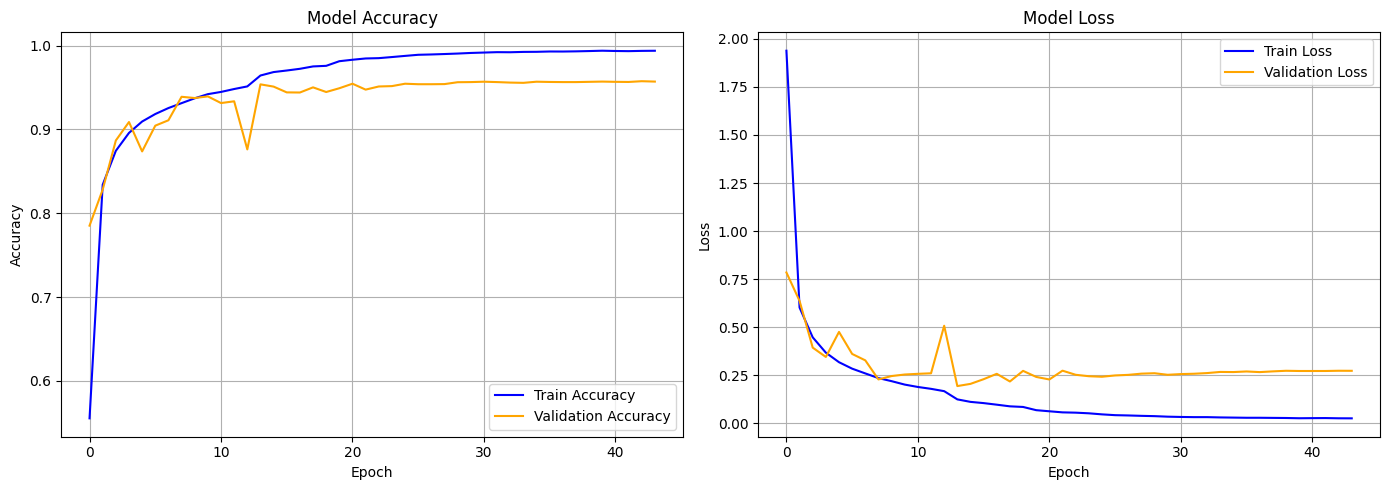

Plots saved as 'training_history.png'


In [6]:
print("Generating predictions...")
y_pred_probs = model.predict(test_inputs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Tính toán các metrics
acc = accuracy_score(y_true_classes, y_pred_classes)
prec = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
rec = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
clf_report = classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_)

# 1. Output ra file .txt
result_text = f"""=====================================
MODEL EVALUATION RESULTS (VAR-CNN)
=====================================
Accuracy:  {acc:.4f}
Precision: {prec:.4f}
Recall:    {rec:.4f}

Classification Report:
{clf_report}
"""

with open("evaluation_results.txt", "w") as f:
    f.write(result_text)

print(result_text)
print("Results saved to 'evaluation_results.txt'")

# 2. Plotting History (Accuracy & Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.savefig("training_history.png")
plt.show()
print("Plots saved as 'training_history.png'")